## Neural Network

In [1]:
import os
import torch
import torch.nn as nn
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

from modeling_common import (
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    build_tabular_preprocess,
    load_adult_dataframe,
    split_features_target,
    split_train_test
)
from evaluation_utils import ensure_dir
from notebook_plotting_utils import plot_confusion_matrix_with_labels, plot_metrics_bar_chart

## Load data

In [2]:
df = load_adult_dataframe("census+income/adult.data")
X, y = split_features_target(df)

## Organize features
same process as logistic regression for best comparison

In [3]:
numeric_features = list(NUMERIC_FEATURES)
categorical_features = list(CATEGORICAL_FEATURES)
preprocess = build_tabular_preprocess()

X_train, X_test, y_train, y_test = split_train_test(
    X,
    y,
    test_size=0.25,
    random_state=11,
)

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

## Convert to PyTorch tensors

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

X_train_tensor = torch.tensor(X_train_processed.toarray(), dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_processed.toarray(), dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

Using device: cpu


## Define MLP model
two hidden layers: one of size 64 and the other of size 32

In [5]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 1),
            nn.ReLU(),
            nn.Linear(1, 2)
        )

    def forward(self, x):
        return self.network(x)

model = MLP(X_train_tensor.shape[1]).to(device)


## Train model

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 100

for epoch in range(epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 5/100, Loss: 0.6216
Epoch 10/100, Loss: 0.6055
Epoch 15/100, Loss: 0.5911
Epoch 20/100, Loss: 0.5772
Epoch 25/100, Loss: 0.5587
Epoch 30/100, Loss: 0.5340
Epoch 35/100, Loss: 0.5076
Epoch 40/100, Loss: 0.4834
Epoch 45/100, Loss: 0.4618
Epoch 50/100, Loss: 0.4451
Epoch 55/100, Loss: 0.4314
Epoch 60/100, Loss: 0.4203
Epoch 65/100, Loss: 0.4104
Epoch 70/100, Loss: 0.4018
Epoch 75/100, Loss: 0.3943
Epoch 80/100, Loss: 0.3879
Epoch 85/100, Loss: 0.3823
Epoch 90/100, Loss: 0.3773
Epoch 95/100, Loss: 0.3728
Epoch 100/100, Loss: 0.3687


In [7]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_tensor)
    probs = torch.softmax(outputs, dim=1)
    y_pred_tensor = torch.argmax(outputs, dim=1)

y_pred = y_pred_tensor.cpu().numpy()
y_proba = probs[:, 1].cpu().numpy()

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("MLP Accuracy:", accuracy)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Print learned parameters with feature names and source columns.
feature_names = preprocess.get_feature_names_out()
first_layer = model.network[0]
output_layer = model.network[2]

input_weights = first_layer.weight.detach().cpu().numpy().flatten()
input_bias = first_layer.bias.detach().cpu().numpy().flatten()

def infer_original_column(processed_feature_name):
    suffix = processed_feature_name.split("__", 1)[-1]

    if suffix in numeric_features:
        return suffix

    for col in sorted(categorical_features, key=len, reverse=True):
        if suffix == col or suffix.startswith(f"{col}_"):
            return col

    return suffix

weights_df = pd.DataFrame({
    "processed_feature": feature_names,
    "original_column": [infer_original_column(name) for name in feature_names],
    "weight": input_weights
})

print("\nInput layer weights by feature:")
print(weights_df.to_string(index=False))
print("\nInput layer bias:", input_bias)

print("\nOutput layer weights (from hidden neuron to class logits):")
print(output_layer.weight.detach().cpu().numpy())
print("Output layer bias:", output_layer.bias.detach().cpu().numpy())

MLP Accuracy: 0.8454735290504852

Confusion matrix:
 [[5754  427]
 [ 831 1129]]

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90      6181
           1       0.73      0.58      0.64      1960

    accuracy                           0.85      8141
   macro avg       0.80      0.75      0.77      8141
weighted avg       0.84      0.85      0.84      8141


Input layer weights by feature:
                             processed_feature original_column    weight
                                      num__age             age  0.273747
                            num__education_num   education_num  0.507518
                             num__capital_gain    capital_gain  0.944437
                             num__capital_loss    capital_loss  0.198544
                           num__hours_per_week  hours_per_week  0.299302
                    cat__workclass_Federal-gov       workclass  0.500857
                      ca

,class,precision,recall
0,0,0.873804,0.930917
1,1,0.725578,0.576020


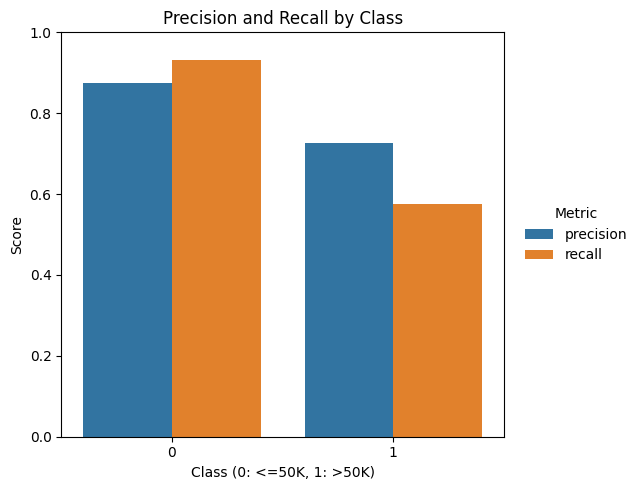

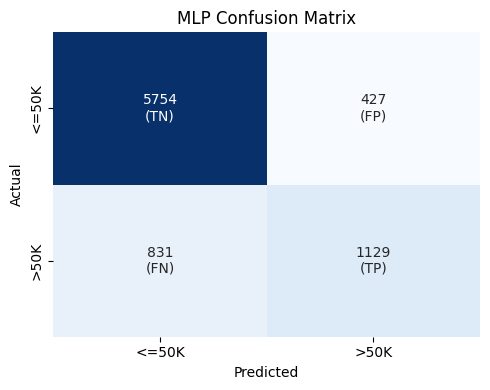

In [8]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

class_rows = [str(c) for c in sorted(set(y_test))]
metrics_df = report_df.loc[class_rows, ["precision", "recall"]].reset_index()
metrics_df = metrics_df.rename(columns={"index": "class"})
metrics_long = metrics_df.melt(id_vars="class", var_name="metric", value_name="score")

display(metrics_df)
plot_metrics_bar_chart(metrics_long)

# Confusion matrix heat map with TN/FP/FN/TP labels (using shared utility)
plot_confusion_matrix_with_labels(cm, title="MLP Confusion Matrix")

In [9]:
ensure_dir(Path("exports"))
mlp_cm_path = os.path.join("exports", "mlp_confusion_matrix.csv")
np.savetxt(mlp_cm_path, cm, fmt="%d", delimiter=",")

mlp_probs_path = os.path.join("exports", "mlp_probs.csv")
np.savetxt(mlp_probs_path, np.column_stack([y_test.to_numpy(), y_proba]), delimiter=",")

print(f"Saved MLP confusion matrix to: {mlp_cm_path}")
print(f"Saved MLP probabilities to: {mlp_probs_path}")

Saved MLP confusion matrix to: exports\mlp_confusion_matrix.csv
Saved MLP probabilities to: exports\mlp_probs.csv
